Model Accuracy: 1.0


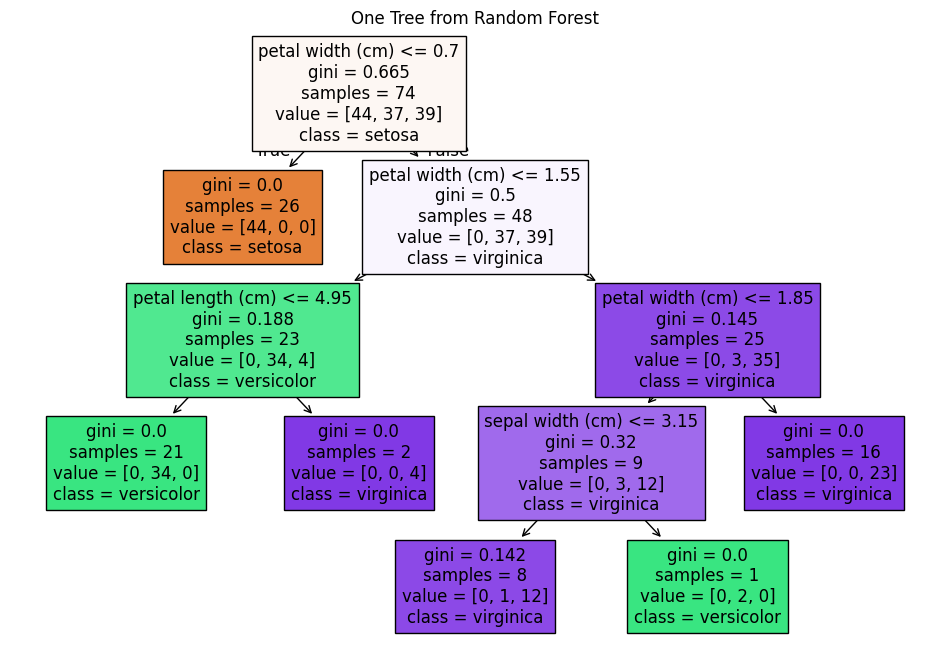


Feature Importance:
sepal length (cm): 0.105
sepal width (cm): 0.021
petal length (cm): 0.450
petal width (cm): 0.424


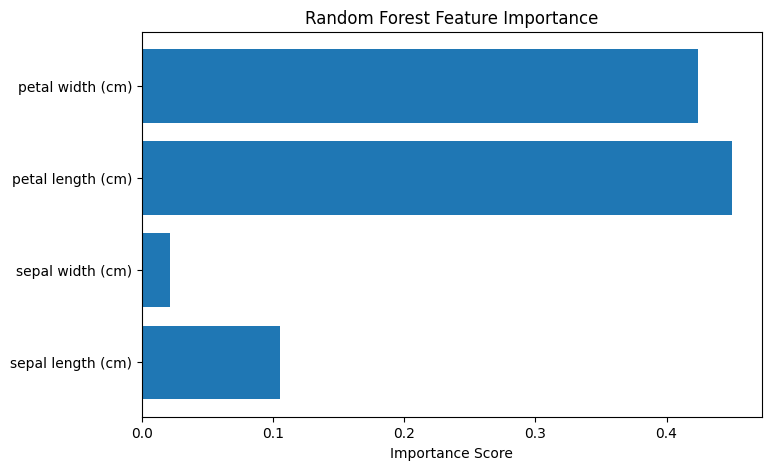

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier   # बदल here
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# ---------------- One Tree Visualization ----------------
# Random Forest has multiple trees → show only one
plt.figure(figsize=(12, 8))
plot_tree(
    model.estimators_[0],   # 👈 first tree
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True
)
plt.title("One Tree from Random Forest")
plt.show()

# ---------------- Feature Importance ----------------
importance = model.feature_importances_

print("\nFeature Importance:")
for i, v in enumerate(importance):
    print(f"{data.feature_names[i]}: {v:.3f}")

# Plot feature importance
plt.figure(figsize=(8, 5))
plt.barh(data.feature_names, importance)
plt.xlabel("Importance Score")
plt.title("Random Forest Feature Importance")
plt.show()